<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/AIFFEL_quest_rs/blob/main/Exploration/Ex07/sentencepiece.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh
%cd ..

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-08-12 06:54:04--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.25, 104.192.142.24, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.25|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-12 06:54:04 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change Directory to /content
from

Sentencepiece 다운로드

In [2]:
!pip install torch numpy matplotlib sentencepiece

라이브러리 불러오기 / 시드 고정

In [3]:
import os
import re
import random
import urllib.request
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

하이퍼파라미터

In [5]:
CONFIG = {
    # 데이터
    'min_len': 1,          # 문장 최소 길이(문자 수)
    'max_len': 150,         # 문장 최대 길이(문자 수)
    'val_ratio': 0.1,       # train 중 검증셋 비율

    # SentencePiece
    'vocab_size': 8000,
    'model_type': 'unigram',   # unigram or bpe
    'character_coverage': 0.9995,

    # 시퀀스/모델 공통
    'max_seq_len': 40,      # 패딩/자르기 기준 (토큰 개수)
    'embedding_dim': 128,
    'hidden_dim': 128,
    'num_layers': 1,
    'dropout': 0.3,
    'num_classes': 2,

    # CNN 전용
    'num_filters': 128,
    'kernel_sizes': [3, 4, 5],

    # 학습
    'batch_size': 128,
    'lr': 1e-3,
    'epochs': 5,
    'patience': 2,           # 조기 종료 patience (val loss 기준)
}

데이터 다운로드 (네이버 영화리뷰)

In [6]:
DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_URL = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt'
TEST_URL = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'
train_path = os.path.join(DATA_DIR, 'ratings_train.txt')
test_path = os.path.join(DATA_DIR, 'ratings_test.txt')

if not os.path.exists(train_path):
    urllib.request.urlretrieve(TRAIN_URL, train_path)
if not os.path.exists(test_path):
    urllib.request.urlretrieve(TEST_URL, test_path)


def load_nsmc(path):
    sentences, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        next(f)  # header: id \t document \t label
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) != 3:
                continue
            _id, doc, label = parts
            if doc.strip() == '':
                continue
            sentences.append(doc)
            labels.append(int(label))
    return sentences, labels


train_sentences, train_labels = load_nsmc(train_path)
test_sentences, test_labels = load_nsmc(test_path)
print('train:', len(train_sentences), 'test:', len(test_sentences))

train: 149995 test: 49997


자연어 노이즈 정리 + 데이터 분석
- 한글/영어/숫자/일부 문장부호 외 잡음 제거
- 중복 문장 제거
- 길이 분포 확인 후 이상치(너무 짧거나 긴 문장) 필터링

문장 수: 149995
최단 길이: 1 / 최장 길이: 158 / 평균 길이: 35


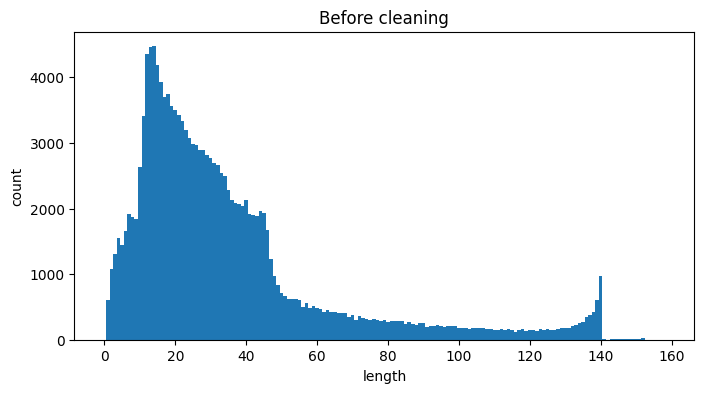

문장 수: 145978
최단 길이: 1 / 최장 길이: 140 / 평균 길이: 35


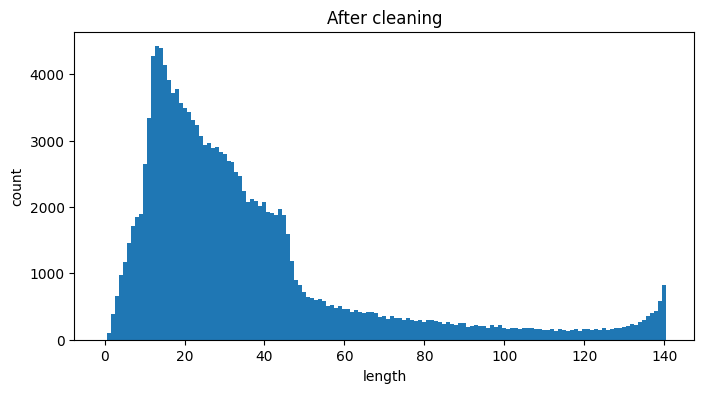

정제 후 train: 145978 test: 49102
Counter({0: 73264, 1: 72714})
train/val/test: 131381 14597 49102


In [7]:
def clean_text(sentence: str) -> str:
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9.,!?~ ]', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence


def pad_punctuation(sentence: str, punc):
    for p in punc:
        sentence = sentence.replace(p, ' ' + p + ' ')
    return re.sub(r'\s+', ' ', sentence).strip()


def analyze_length(corpus, title='Sentence Length Distribution'):
    lengths = [len(s) for s in corpus]
    print(f'문장 수: {len(corpus)}')
    print(f'최단 길이: {min(lengths)} / 최장 길이: {max(lengths)} / 평균 길이: {sum(lengths)//len(lengths)}')
    max_len = max(lengths)
    dist = np.zeros(max_len + 1, dtype=int)
    for l in lengths:
        dist[l] += 1
    plt.figure(figsize=(8, 4))
    plt.bar(range(max_len + 1), dist, width=1.0)
    plt.title(title)
    plt.xlabel('length')
    plt.ylabel('count')
    plt.show()
    return lengths


def clean_corpus(sentences, labels, min_len, max_len):
    cleaned_sentences, cleaned_labels = [], []
    seen = set()
    for s, y in zip(sentences, labels):
        c = clean_text(s)
        if c == '' or c in seen:
            continue
        if len(c) < min_len or len(c) >= max_len:
            continue
        seen.add(c)
        cleaned_sentences.append(c)
        cleaned_labels.append(y)
    return cleaned_sentences, cleaned_labels


# 정제 전 분포 확인
_ = analyze_length(train_sentences, 'Before cleaning')

train_sentences_c, train_labels_c = clean_corpus(
    train_sentences, train_labels, CONFIG['min_len'], CONFIG['max_len']
)
test_sentences_c, test_labels_c = clean_corpus(
    test_sentences, test_labels, CONFIG['min_len'], CONFIG['max_len']
)

# 정제 후 분포 확인
_ = analyze_length(train_sentences_c, 'After cleaning')
print('정제 후 train:', len(train_sentences_c), 'test:', len(test_sentences_c))
print(Counter(train_labels_c))

# train / val 분리
idx = list(range(len(train_sentences_c)))
random.shuffle(idx)
n_val = int(len(idx) * CONFIG['val_ratio'])
val_idx, tr_idx = idx[:n_val], idx[n_val:]

tr_sentences = [train_sentences_c[i] for i in tr_idx]
tr_labels = [train_labels_c[i] for i in tr_idx]
val_sentences = [train_sentences_c[i] for i in val_idx]
val_labels = [train_labels_c[i] for i in val_idx]

print('train/val/test:', len(tr_sentences), len(val_sentences), len(test_sentences_c))

SentencePiece 토크나이저 학습

In [8]:
def train_sentencepiece(corpus, model_prefix, vocab_size, model_type, character_coverage):
    corpus_path = f'{model_prefix}_corpus.txt'
    with open(corpus_path, 'w', encoding='utf-8') as f:
        for line in corpus:
            f.write(line + '\n')

    spm.SentencePieceTrainer.Train(
        f'--input={corpus_path} --model_prefix={model_prefix} '
        f'--vocab_size={vocab_size} --model_type={model_type} '
        f'--character_coverage={character_coverage} '
        f'--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
    )
    sp = spm.SentencePieceProcessor()
    sp.Load(f'{model_prefix}.model')
    return sp


sp_model_prefix = f"nsmc_spm_{CONFIG['model_type']}_{CONFIG['vocab_size']}"
sp = train_sentencepiece(
    tr_sentences, sp_model_prefix,
    CONFIG['vocab_size'], CONFIG['model_type'], CONFIG['character_coverage']
)
SP_VOCAB_SIZE = sp.GetPieceSize()

sample = tr_sentences[0]
print('원문:', sample)
print('encode ids:', sp.EncodeAsIds(sample))
print('encode pieces:', sp.EncodeAsPieces(sample))
print('decode:', sp.DecodeIds(sp.EncodeAsIds(sample)))

PAD_ID = sp.pad_id()

원문: 재밌음 왠지영화친구의 느낌이풍겼었다 이상하게,,,
encode ids: [1062, 2165, 32, 2239, 10, 885, 1769, 2736, 334, 4810, 790]
encode pieces: ['▁재밌음', '▁왠지', '영화', '친구', '의', '▁느낌이', '풍', '겼', '었다', '▁이상하게', ',,,']
decode: 재밌음 왠지영화친구의 느낌이풍겼었다 이상하게,,,


데이터셋 / 데이터로더

In [9]:
class TextClassificationDataset(Dataset):
    def __init__(self, sentences, labels, encode_fn, max_seq_len, pad_id=0):
        self.sentences = sentences
        self.labels = labels
        self.encode_fn = encode_fn
        self.max_seq_len = max_seq_len
        self.pad_id = pad_id

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        ids = self.encode_fn(self.sentences[idx])[: self.max_seq_len]
        if len(ids) == 0:
            ids = [self.pad_id]
        return torch.tensor(ids, dtype=torch.long), self.labels[idx]


def make_collate_fn(pad_id):
    def collate_fn(batch):
        seqs, labels = zip(*batch)
        lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
        padded = pad_sequence(seqs, batch_first=True, padding_value=pad_id)
        labels = torch.tensor(labels, dtype=torch.long)
        return padded, lengths, labels
    return collate_fn


def build_dataloaders(encode_fn, pad_id, vocab_size, batch_size, max_seq_len):
    train_ds = TextClassificationDataset(tr_sentences, tr_labels, encode_fn, max_seq_len, pad_id)
    val_ds = TextClassificationDataset(val_sentences, val_labels, encode_fn, max_seq_len, pad_id)
    test_ds = TextClassificationDataset(test_sentences_c, test_labels_c, encode_fn, max_seq_len, pad_id)

    collate_fn = make_collate_fn(pad_id)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    return train_loader, val_loader, test_loader


sp_encode_fn = lambda s: sp.EncodeAsIds(s)
train_loader, val_loader, test_loader = build_dataloaders(
    sp_encode_fn, PAD_ID, SP_VOCAB_SIZE, CONFIG['batch_size'], CONFIG['max_seq_len']
)

xb, lb, yb = next(iter(train_loader))
print(xb.shape, lb.shape, yb.shape)

torch.Size([128, 40]) torch.Size([128]) torch.Size([128])


모델 정의 (LSTM / 1D-CNN / GlobalMaxPooling)

In [10]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers,
                 num_classes, dropout, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        # h_n: (num_layers*2, batch, hidden_dim) -> 마지막 layer의 양방향 concat
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat([h_forward, h_backward], dim=1)
        h = self.dropout(h)
        return self.fc(h)


class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, kernel_sizes,
                 num_classes, dropout, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x, lengths=None):
        emb = self.embedding(x)
        emb = emb.transpose(1, 2)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(emb))
            p = torch.max(c, dim=2).values
            pooled.append(p)
        h = torch.cat(pooled, dim=1)
        h = self.dropout(h)
        return self.fc(h)


class GlobalMaxPoolClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, dropout, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, lengths=None):
        emb = self.embedding(x)
        pooled = torch.max(emb, dim=1).values
        return self.fc(self.dropout(pooled))


def build_model(name, vocab_size, cfg, pad_id):
    if name == 'lstm':
        return LSTMClassifier(
            vocab_size, cfg['embedding_dim'], cfg['hidden_dim'], cfg['num_layers'],
            cfg['num_classes'], cfg['dropout'], pad_id,
        )
    elif name == 'cnn':
        return CNNClassifier(
            vocab_size, cfg['embedding_dim'], cfg['num_filters'], cfg['kernel_sizes'],
            cfg['num_classes'], cfg['dropout'], pad_id,
        )
    elif name == 'gmp':
        return GlobalMaxPoolClassifier(
            vocab_size, cfg['embedding_dim'], cfg['num_classes'], cfg['dropout'], pad_id,
        )
    else:
        raise ValueError(name)

학습 / 평가 루프

In [11]:
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    with torch.set_grad_enabled(train_mode):
        for xb, lb, yb in loader:
            xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)
            logits = model(xb, lb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * yb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += yb.size(0)

    return total_loss / total_count, total_correct / total_count


def train_model(model, train_loader, val_loader, cfg):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best_val_loss = float('inf')
    best_state = None
    patience_left = cfg['patience']

    for epoch in range(1, cfg['epochs'] + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)
        print(f'[epoch {epoch}] train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} '
              f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_left = cfg['patience']
        else:
            patience_left -= 1
            if patience_left <= 0:
                print('Early stopping.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def evaluate(model, loader):
    _, acc = run_epoch(model, loader, optimizer=None)
    return acc

SentencePiece 기반 모델 학습 (LSTM, CNN, GMP)

In [12]:
results = {}

for model_name in ['lstm', 'cnn', 'gmp']:
    print(f'\n==== SentencePiece({CONFIG["model_type"]}) + {model_name.upper()} ====')
    model = build_model(model_name, SP_VOCAB_SIZE, CONFIG, PAD_ID)
    model = train_model(model, train_loader, val_loader, CONFIG)
    test_acc = evaluate(model, test_loader)
    print(f'{model_name.upper()} test accuracy: {test_acc:.4f}')
    results[f'sp_{CONFIG["model_type"]}_{model_name}'] = test_acc


==== SentencePiece(unigram) + LSTM ====
[epoch 1] train_loss=0.4646 train_acc=0.7741 val_loss=0.3771 val_acc=0.8323
[epoch 2] train_loss=0.3298 train_acc=0.8568 val_loss=0.3477 val_acc=0.8476
[epoch 3] train_loss=0.2752 train_acc=0.8837 val_loss=0.3486 val_acc=0.8470
[epoch 4] train_loss=0.2254 train_acc=0.9078 val_loss=0.3703 val_acc=0.8497
Early stopping.
LSTM test accuracy: 0.8433

==== SentencePiece(unigram) + CNN ====
[epoch 1] train_loss=0.5169 train_acc=0.7359 val_loss=0.4104 val_acc=0.8109
[epoch 2] train_loss=0.3686 train_acc=0.8360 val_loss=0.3595 val_acc=0.8415
[epoch 3] train_loss=0.3146 train_acc=0.8653 val_loss=0.3504 val_acc=0.8477
[epoch 4] train_loss=0.2840 train_acc=0.8795 val_loss=0.3559 val_acc=0.8509
[epoch 5] train_loss=0.2549 train_acc=0.8942 val_loss=0.3612 val_acc=0.8524
Early stopping.
CNN test accuracy: 0.8463

==== SentencePiece(unigram) + GMP ====
[epoch 1] train_loss=0.6900 train_acc=0.5685 val_loss=0.6210 val_acc=0.6696
[epoch 2] train_loss=0.6022 train_

토크나이저 비교 실험

(CNN모델로 비교하였다 -> CNN은 병렬 처리로 LSTM보다 빠르면서, GMP보다는 표현력이 있어서 토크나이저 차이를 잘 반영하기 때문에 선택하였다)
- unigram vs bpe -> 모델 타입을 바꿔서 알고리즘 차이를 보기위해
- SentencePiece vs 형태소 기반(Mecab) 단어 토크나이저

-> 동일한 데이터/모델/하이퍼파라미터 조건에서 비교한다.

In [13]:
def run_experiment(tag, encode_fn, vocab_size, pad_id, model_name='cnn'):
    tr_loader, va_loader, te_loader = build_dataloaders(
        encode_fn, pad_id, vocab_size, CONFIG['batch_size'], CONFIG['max_seq_len']
    )
    model = build_model(model_name, vocab_size, CONFIG, pad_id)
    model = train_model(model, tr_loader, va_loader, CONFIG)
    acc = evaluate(model, te_loader)
    print(f'[{tag}] test accuracy: {acc:.4f}')
    results[tag] = acc
    return acc


# 1.bpe 옵션 비교
bpe_prefix = f"nsmc_spm_bpe_{CONFIG['vocab_size']}"
sp_bpe = train_sentencepiece(
    tr_sentences, bpe_prefix, CONFIG['vocab_size'], 'bpe', CONFIG['character_coverage']
)
run_experiment('sp_bpe_cnn', lambda s: sp_bpe.EncodeAsIds(s), CONFIG['vocab_size'], sp_bpe.pad_id())

# 2.더 작은 vocab_size 비교
small_vocab = 4000
small_prefix = f"nsmc_spm_{CONFIG['model_type']}_{small_vocab}"
sp_small = train_sentencepiece(
    tr_sentences, small_prefix, small_vocab, CONFIG['model_type'], CONFIG['character_coverage']
)
run_experiment(
    f'sp_{CONFIG["model_type"]}_vocab{small_vocab}_cnn',
    lambda s: sp_small.EncodeAsIds(s), small_vocab, sp_small.pad_id(),
)

# 3. Mecab 형태소 분석 기반 단어 토크나이저와 비교
from konlpy.tag import Mecab
mecab = Mecab()

word_counter = Counter()
for s in tr_sentences:
    word_counter.update(mecab.morphs(s))

MECAB_VOCAB_SIZE = min(CONFIG['vocab_size'], len(word_counter) + 4)
most_common = [w for w, _ in word_counter.most_common(MECAB_VOCAB_SIZE - 4)]
# 0:pad, 1:unk 을 SentencePiece 설정과 맞춰줌
mecab_word2id = {'<pad>': 0, '<unk>': 1, '<s>': 2, '</s>': 3}
for w in most_common:
    mecab_word2id[w] = len(mecab_word2id)


def mecab_encode(sentence):
    return [mecab_word2id.get(tok, 1) for tok in mecab.morphs(sentence)]


run_experiment('mecab_word_cnn', mecab_encode, len(mecab_word2id), 0)

[epoch 1] train_loss=0.5175 train_acc=0.7353 val_loss=0.4032 val_acc=0.8148
[epoch 2] train_loss=0.3692 train_acc=0.8360 val_loss=0.3601 val_acc=0.8383
[epoch 3] train_loss=0.3203 train_acc=0.8625 val_loss=0.3495 val_acc=0.8457
[epoch 4] train_loss=0.2896 train_acc=0.8774 val_loss=0.3467 val_acc=0.8485
[epoch 5] train_loss=0.2645 train_acc=0.8896 val_loss=0.3656 val_acc=0.8434
[sp_bpe_cnn] test accuracy: 0.8493
[epoch 1] train_loss=0.5002 train_acc=0.7483 val_loss=0.3874 val_acc=0.8313
[epoch 2] train_loss=0.3724 train_acc=0.8329 val_loss=0.3619 val_acc=0.8388
[epoch 3] train_loss=0.3293 train_acc=0.8570 val_loss=0.3621 val_acc=0.8357
[epoch 4] train_loss=0.2985 train_acc=0.8718 val_loss=0.3737 val_acc=0.8380
Early stopping.
[sp_unigram_vocab4000_cnn] test accuracy: 0.8369
[epoch 1] train_loss=0.4498 train_acc=0.7824 val_loss=0.3642 val_acc=0.8366
[epoch 2] train_loss=0.3466 train_acc=0.8479 val_loss=0.3431 val_acc=0.8497
[epoch 3] train_loss=0.3015 train_acc=0.8709 val_loss=0.3339 val

0.8570119343407601

결과 비교 정리


 최종 비교 결과 
mecab_word_cnn                : 0.8570
sp_bpe_cnn                    : 0.8493
sp_unigram_cnn                : 0.8463
sp_unigram_lstm               : 0.8433
sp_unigram_vocab4000_cnn      : 0.8369
sp_unigram_gmp                : 0.8146


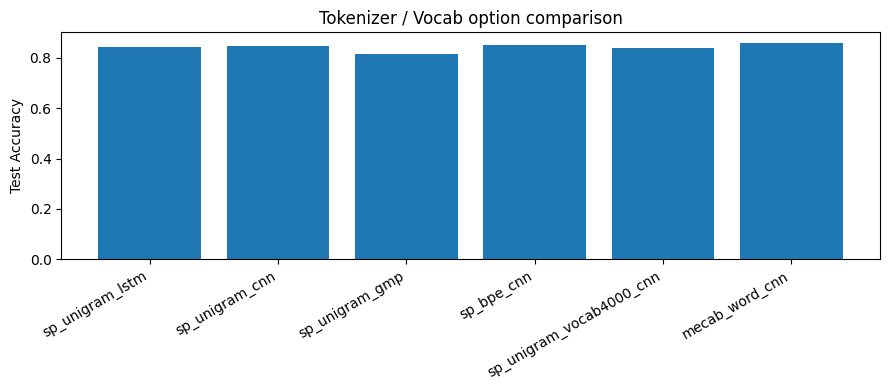

In [14]:
print('\n 최종 비교 결과 ')
for k, v in sorted(results.items(), key=lambda x: -x[1]):
    print(f'{k:30s}: {v:.4f}')

names = list(results.keys())
values = [results[n] for n in names]
plt.figure(figsize=(9, 4))
plt.bar(names, values)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Test Accuracy')
plt.title('Tokenizer / Vocab option comparison')
plt.tight_layout()
plt.show()

### SentencePiece 옵션 및 모델별 성능 비교 분석

#### 1. 실험 결과 요약
| 실험 항목 | 토크나이저 / 옵션 | Vocab Size | 모델 구조 | Test Accuracy |
| :---: | :---: | :---: | :---: | :---: |
| 실험 1 | 형태소 기반(Mecab) 단어 토크나이저 | 8,000 | 1D-CNN | **85.70%** (최고 성능) |
| 실험 2 | SentencePiece (BPE) | 8,000 | 1D-CNN | **84.93%** |
| 실험 3 | SentencePiece (Unigram) | 8,000 | 1D-CNN | **84.63%** |
| 실험 4 | SentencePiece (Unigram) | 8,000 | 양방향 LSTM | **84.33%** |
| 실험 5 | SentencePiece (Unigram) | 4,000 | 1D-CNN | **83.69%** |
| 실험 6 | SentencePiece (Unigram) |8,000	| GlobalMaxPool|**81.46%**|

---

#### 2. 결과 분석

1. **SentencePiece vs 형태소 기반(Mecab) 단어 토크나이저**

동일 조건(CNN, Vocab 8,000)에서 Mecab 형태소 분석 기반 단어 토크나이저(85.70%)가 SentencePiece 계열(84.63 ~ 84.93%)보다 0.8~1.1%p 더 높은 정확도를 기록했다.
 그러나, 정확도만 보면 Mecab이 우세하지만, 언어 독립성,구축 편의성까지 고려하면 상충관계가 존재한다고 본다.

2. **SentencePiece 알고리즘 비교 (BPE vs. Unigram)**

동일 조건(CNN, Vocab 8,000)에서 BPE(84.93%)가 Unigram(84.63%)보다 약 0.3%p 높은 정확도를 기록했다. 다만,차이가 0.3%p 수준으로 크지 않아, 이 데이터셋에서는 두 알고리즘 간 성능 차이가 통계적으로 유의미하다고 단정하기는 어렵다.

3. **단어장 크기(Vocab Size) 영향 비교 (8,000 vs. 4,000)**

Vocab Size를 8,000에서 4,000으로 줄였을 때 정확도가 84.63%에서 83.69%로 약 0.94%p 하락했다.
단어장 크기가 작아지면 희귀 표현이 더 잘게 쪼개지거나 Unknown 처리되는 비율이 늘어나면서, 문맥적 의미를 압축해서 담아내는 능력이 떨어지는 것으로 보인다.

4. **분류 모델 구조별 성능 비교 (CNN vs. LSTM vs. GlobalMaxPool)**

CNN(84.63%)과 양방향 LSTM(84.33%)은 0.3%p 차이로 유사하게 우수한 성능을 보였으나, 학습 속도 측면에서는 병렬 처리가 가능한 CNN이 더 효율적이었다.
GlobalMaxPool 단독 모델(81.46%)은 임베딩 위에서 바로 최댓값만 뽑는 가장 단순한 구조라, 지역적 패턴이나 순서 정보를 전혀 활용하지 못해 다른 두 모델 대비 3%p 이상 낮은 성능을 보였다.

---

#### 3. 결론
- 이번 프로젝트에서 SentencePiece(BPE/Unigram) 서브워드 토크나이저와 Mecab 형태소 기반 단어 토크나이저를 동일 조건에서 비교한 결과, Mecab 기반 토크나이저가 85.70%로 가장 높은 test accuracy를 기록했고, SentencePiece 계열(83.69~84.93%)이 그 뒤를 이었다. 모든 조합이 80% 이상의 정확도를 달성해 목표 기준을 충족했다.

### 회고
저번 프로젝트에서는 하이퍼파라미터로 같은 조건을 설정해두지 않고 프로젝트를 진행해서 정확도 부분에서 좀 아쉬웠다. 그래서 이번에는 잊지않고 하이퍼파라미터와 시드를 고정하여 조건을 고정해두어 좀 더 신뢰성 / 정확도 가 있는 결과가 나온것같아 좋은 것 같다.